# Injection/PT-Dip 판정 방법론 점검

`Injection_PT_Dip_Analysis.ipynb`를 보고 나온 후속 질문들을 검증한다:

1. 3% 하락 임계치가 압력대와 무관하게 적당한지
2. 사출은 사이클 안에서 몇 틱 간격/어느 위치에 있는지
3. 증압/SV 전환 후 안정기 진입까지 몇 틱이 걸리는지, 범위별로 다른지
4. 롤링 baseline(직전 3틱 평균)에 사출 여파가 섞여 들어가는지
5. "사출인데 압력이 안 떨어진" 사례가 진짜인지, 측정 방식(baseline 창 크기/하락 판정 시점) 문제인지

전부 `Injection_Dip_Analyzer.py`에 새로 추가한 `settle_ticks()` / `injection_spacing()` /
`injection_events(..., before_ticks=, after_ticks=)` 를 그대로 쓴다.

In [1]:
import os, sys, pickle
ROOT_DIR = os.path.dirname(os.getcwd())
sys.path.insert(0, ROOT_DIR); sys.path.insert(0, os.getcwd())

import numpy as np, pandas as pd
import matplotlib, matplotlib.pyplot as plt
matplotlib.rcParams["font.family"] = "Malgun Gothic"
matplotlib.rcParams["axes.unicode_minus"] = False

import Injection_Dip_Analyzer as D
from Cycle_Feature_Extractor import DIP_THRESHOLD_PCT, STEADY_TICK_MIN, RAMP_THRESHOLD_PCT, INJECTION_DIP_TICKS

pd.set_option("display.width", 200)

PUMP_ID = "P1"
OUT = "analysis_out/injection_pt_dip_review"
os.makedirs(OUT, exist_ok=True)

BLUE, ORANGE, AQUA, RED = "#2a78d6", "#eb6834", "#1baf7a", "#d03b3b"
GRID, MUTED, INK, INK2 = "#e1e0d9", "#898781", "#0b0b0b", "#52514e"

with open("cache/viewer_cycle_P1.pkl", "rb") as f:
    store = pickle.load(f)
raw = store["raw"]
print("데이터 구간:", raw.index.min(), "~", raw.index.max())

데이터 구간: 2026-09-10 16:00:00.406338 ~ 2026-09-23 14:16:02.599686


## 1. 3% 임계값이 압력대와 무관하게 적당한가

"사출 없이 떨어진 것" 판정 대상이 되는 **모든 안정구간 틱** (사출 설명구간도 아니고,
Tick_Index>=2인 틱 전체 - 실제로 걸린 것만이 아니라 판정 자체가 이뤄지는 모집단)을 놓고,
직전 3틱 평균 PT(baseline) 구간별로 자연스러운 틱-틱 변동폭이 얼마나 다른지 본다.

In [2]:
df, t = D.prep(raw, PUMP_ID)
df_on = df[df["_buildup"] == 1].sort_values("Time").copy()
df_on["Tick_Index"] = df_on.groupby("Cycle_ID").cumcount()

pt_roll_cur = df_on.groupby("Cycle_ID")[t["PT"]].transform(lambda s: s.rolling(3, min_periods=1).mean())
pt_roll = pd.Series(pt_roll_cur.values, index=df_on.index).groupby(df_on["Cycle_ID"]).shift(1)

no_shot = df_on["Shot_Owned_Active"] == 0
steady_mask = df_on["Tick_Index"] >= STEADY_TICK_MIN
eligible = no_shot & steady_mask & pt_roll.notna()

pt_base = pt_roll[eligible]
pt_now = df_on.loc[eligible, t["PT"]]
drop_abs = pt_base - pt_now
drop_pct = drop_abs / pt_base.replace(0, np.nan) * 100
flagged = drop_pct >= DIP_THRESHOLD_PCT * 100

edges = np.arange(70, 160, 10)
bins = pd.cut(pt_base, edges)
gdf = pd.DataFrame({"bin": bins, "drop_abs": drop_abs, "drop_pct": drop_pct, "flagged": flagged})
gsum = gdf.groupby("bin", observed=True).agg(
    n=("drop_abs", "size"), std_abs=("drop_abs", "std"), std_pct=("drop_pct", "std"),
    flag_rate=("flagged", "mean"))
gsum["flag_rate"] *= 100
gsum.to_csv(f"{OUT}/pt_bin_threshold_diagnostics_{PUMP_ID}.csv", encoding="utf-8-sig")
gsum.round(3)

,n,std_abs,std_pct,flag_rate
bin,,,,
"(70, 80]",4515,4.476,5.803,0.000
"(80, 90]",27659,10.285,11.968,3.095
"(90, 100]",74809,7.964,8.407,8.006
"(100, 110]",53627,7.440,7.130,7.420
"(110, 120]",29347,5.568,4.884,4.338
"(120, 130]",36889,3.280,2.638,6.070
"(130, 140]",10882,3.775,2.814,9.934
"(140, 150]",1287,3.881,2.725,9.713


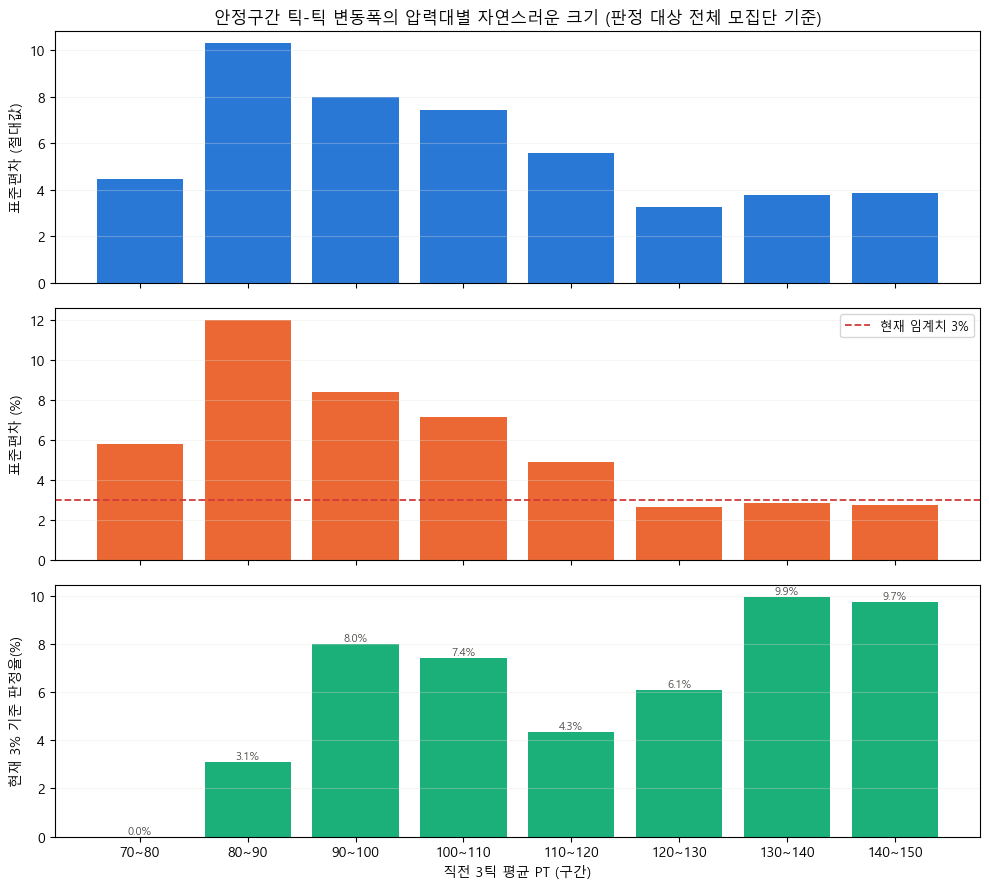

In [3]:
labels = [f"{int(iv.left)}~{int(iv.right)}" for iv in gsum.index]

fig, axes = plt.subplots(3, 1, figsize=(10, 9), sharex=True)
axes[0].bar(labels, gsum["std_abs"], color=BLUE)
axes[0].set_ylabel("표준편차 (절대값)")
axes[0].set_title("안정구간 틱-틱 변동폭의 압력대별 자연스러운 크기 (판정 대상 전체 모집단 기준)")
axes[0].grid(alpha=.3, color=GRID, axis="y")

axes[1].bar(labels, gsum["std_pct"], color=ORANGE)
axes[1].set_ylabel("표준편차 (%)")
axes[1].axhline(DIP_THRESHOLD_PCT * 100, color=RED, ls="--", lw=1.3,
                label=f"현재 임계치 {DIP_THRESHOLD_PCT*100:.0f}%")
axes[1].legend(fontsize=9)
axes[1].grid(alpha=.3, color=GRID, axis="y")

axes[2].bar(labels, gsum["flag_rate"], color=AQUA)
for i, v in enumerate(gsum["flag_rate"]):
    axes[2].text(i, v, f"{v:.1f}%", ha="center", va="bottom", fontsize=8, color=INK2)
axes[2].set_ylabel("현재 3% 기준 판정율(%)")
axes[2].set_xlabel("직전 3틱 평균 PT (구간)")
axes[2].grid(alpha=.3, color=GRID, axis="y")
plt.tight_layout()
plt.savefig(f"{OUT}/01_threshold_by_pt_bin.png", dpi=140)
plt.show()

**읽는 법**: 자연 변동폭(위 두 패널)이 80~90 구간에서 유독 크고(표준편차 10 이상,
%로도 12%) 120~130 구간에서 유독 작다(3~4대). 그런데 현재 3% 고정 임계값으로는
130~150 구간의 판정율이 오히려 가장 높다(9.7~9.9%) - 즉 **자연 변동폭과 판정 민감도가
압력대별로 반비례하듯 어긋난다.** 다만 판정율 자체는 std만으로 단순 설명되지 않는
비선형적 패턴(80~90이 3.1%로 오히려 낮음)도 있어 - 왜곡의 방향이 "낮은 압력=항상 과다판정"
처럼 단순하지 않다. 결론: **고정 3%보다는 압력대별(혹은 사이클별 rolling std 기반) 적응형
임계치가 이론적으로 더 타당해 보이지만, 80~90 구간의 높은 변동성 자체가 안정구간이
아직 덜 끝난 과도기 데이터가 섞인 결과일 수 있다** - 아래 3절(안정기 진입 시점)과 함께
보는 게 맞다.

## 2. 사출은 사이클 안에서 몇 틱 간격으로, 어느 위치에서 일어나는가

In [4]:
sp = D.injection_spacing(raw, PUMP_ID)
print("사이클당 사출 횟수:")
print(sp["n_inj_per_cycle"].value_counts().sort_index())
print(f"\n다중사출 사이클의 사출-사출 틱 간격 (n={len(sp['gaps']):,}):")
print(pd.Series(sp["gaps"]).describe())
print(f"\n단일사출 사이클의 사출 시작 Tick_Index (n={len(sp['start_tick_index']):,}):")
print(pd.Series(sp["start_tick_index"]).describe())
print(f"\n사이클 길이(N_Ticks):")
print(sp["cycle_len"].describe())

사이클당 사출 횟수:
inj_start
0      110
1    31971
2     1009
Name: count, dtype: int64

다중사출 사이클의 사출-사출 틱 간격 (n=1,009):
count    1009.000000
mean       10.254708
std         0.672253
min         7.000000
25%        10.000000
50%        10.000000
75%        11.000000
max        11.000000
dtype: float64

단일사출 사이클의 사출 시작 Tick_Index (n=31,971):
count    31971.000000
mean         5.484376
std          1.771450
min          0.000000
25%          4.000000
50%          6.000000
75%          7.000000
max         10.000000
dtype: float64

사이클 길이(N_Ticks):
count    33090.000000
mean        15.699970
std          2.270286
min          1.000000
25%         15.000000
50%         16.000000
75%         16.000000
max         82.000000
Name: Cycle_Len, dtype: float64


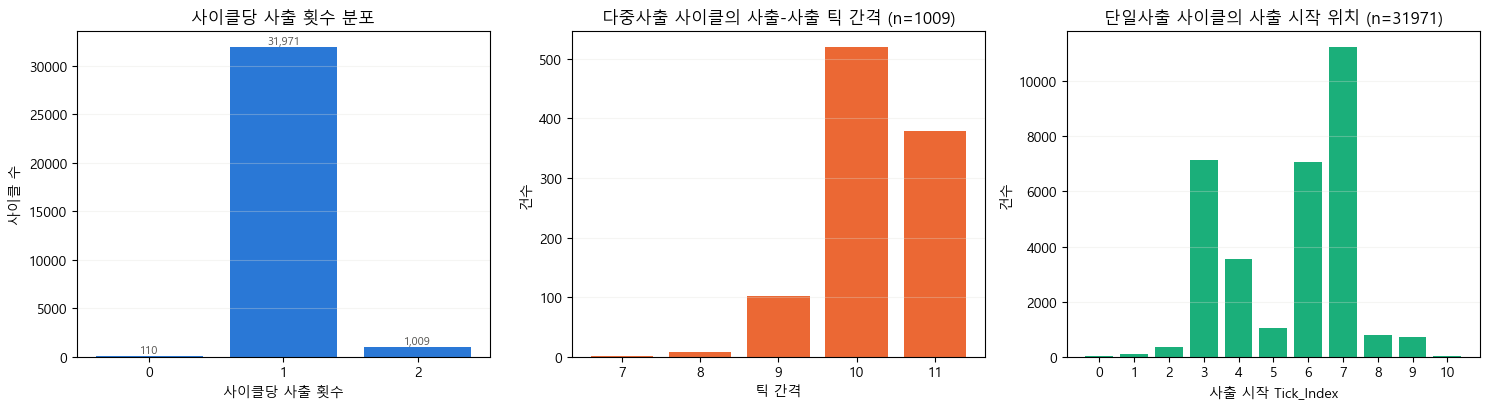

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))
vc = sp["n_inj_per_cycle"].value_counts().sort_index()
axes[0].bar(vc.index.astype(str), vc.values, color=BLUE)
for i, v in enumerate(vc.values):
    axes[0].text(i, v, f"{v:,}", ha="center", va="bottom", fontsize=8, color=INK2)
axes[0].set_xlabel("사이클당 사출 횟수"); axes[0].set_ylabel("사이클 수")
axes[0].set_title("사이클당 사출 횟수 분포")
axes[0].grid(alpha=.3, color=GRID, axis="y")

gap_vc = pd.Series(sp["gaps"]).value_counts().sort_index()
axes[1].bar(gap_vc.index.astype(str), gap_vc.values, color=ORANGE)
axes[1].set_xlabel("틱 간격"); axes[1].set_ylabel("건수")
axes[1].set_title(f"다중사출 사이클의 사출-사출 틱 간격 (n={len(sp['gaps'])})")
axes[1].grid(alpha=.3, color=GRID, axis="y")

st_vc = pd.Series(sp["start_tick_index"]).value_counts().sort_index()
axes[2].bar(st_vc.index.astype(str), st_vc.values, color=AQUA)
axes[2].set_xlabel("사출 시작 Tick_Index"); axes[2].set_ylabel("건수")
axes[2].set_title(f"단일사출 사이클의 사출 시작 위치 (n={len(sp['start_tick_index'])})")
axes[2].grid(alpha=.3, color=GRID, axis="y")
plt.tight_layout()
plt.savefig(f"{OUT}/02_injection_spacing.png", dpi=140)
plt.show()

**읽는 법**: 사이클의 97%(32,980/33,090)는 사출이 1번뿐이고, 3%(1,009개)만 2번
일어난다. 2번 일어나는 경우 간격은 9~11틱으로 매우 일정하다. 단일사출 사이클에서
사출 시작 위치는 **Tick_Index 3~4와 6~7에서 두 번 몰리는(쌍봉) 분포** - 레시피가
최소 두 그룹으로 나뉘어 있을 가능성을 시사한다. 평균 사이클 길이는 약 16틱.

## 3. 증압/SV 전환 후 안정기 진입까지 몇 틱이 걸리는가

`RAMP_THRESHOLD_PCT`(5%) 안으로 FT가 들어오는 데 걸리는 틱수를, 사이클 시작(증압)과
사이클 중간 SV 전환 두 경우 모두에 대해 계산한다.

In [6]:
res = D.settle_ticks(raw, PUMP_ID)
res.to_csv(f"{OUT}/settle_ticks_{PUMP_ID}.csv", index=False, encoding="utf-8-sig")
for kind, g in res.groupby("Kind"):
    print(f"--- {kind} (n={len(g):,}) ---")
    print(g["Ticks_To_Settle"].describe())
    print()

--- ramp_start (n=33,090) ---
count    33090.000000
mean         3.237927
std          0.744565
min          0.000000
25%          3.000000
50%          3.000000
75%          4.000000
max          5.000000
Name: Ticks_To_Settle, dtype: float64

--- sv_change (n=1,013) ---
count    1013.000000
mean        1.969398
std         0.668349
min         0.000000
25%         2.000000
50%         2.000000
75%         2.000000
max         3.000000
Name: Ticks_To_Settle, dtype: float64



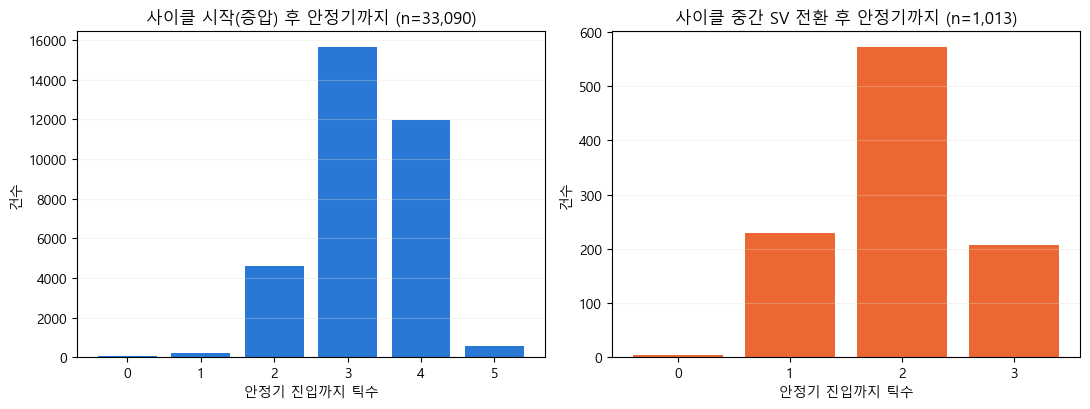

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
for ax, kind, color in [(axes[0], "ramp_start", BLUE), (axes[1], "sv_change", ORANGE)]:
    sub = res[res["Kind"] == kind]
    vc = sub["Ticks_To_Settle"].value_counts().sort_index()
    ax.bar(vc.index.astype(str), vc.values, color=color)
    ax.set_xlabel("안정기 진입까지 틱수"); ax.set_ylabel("건수")
    ax.grid(alpha=.3, color=GRID, axis="y")
axes[0].set_title(f"사이클 시작(증압) 후 안정기까지 (n={len(res[res['Kind']=='ramp_start']):,})")
axes[1].set_title(f"사이클 중간 SV 전환 후 안정기까지 (n={len(res[res['Kind']=='sv_change']):,})")
plt.tight_layout()
plt.savefig(f"{OUT}/03_settle_ticks_hist.png", dpi=140)
plt.show()

**핵심**: 증압 후 안정기 진입은 **평균 3.2틱, 중앙값 3틱, 4틱까지 걸리는 경우도 36%**다.
그런데 `Cycle_Feature_Extractor.STEADY_TICK_MIN=2` 는 Tick_Index>=2부터 "안정구간"으로
친다 - **실제로는 이 시점에 아직 증압이 안 끝난 사이클이 상당수 섞여 있다는 뜻**이다.
1절에서 80~90 구간의 변동폭이 유독 컸던 것도 이 미완료 증압 구간이 섞였기 때문일 수
있다. 반면 사이클 중간 SV 전환은 훨씬 빨리(중앙값 2틱) 안정된다 - 이미 펌프가 돌고
있는 상태에서의 미세 조정이라 그런 것으로 보인다.

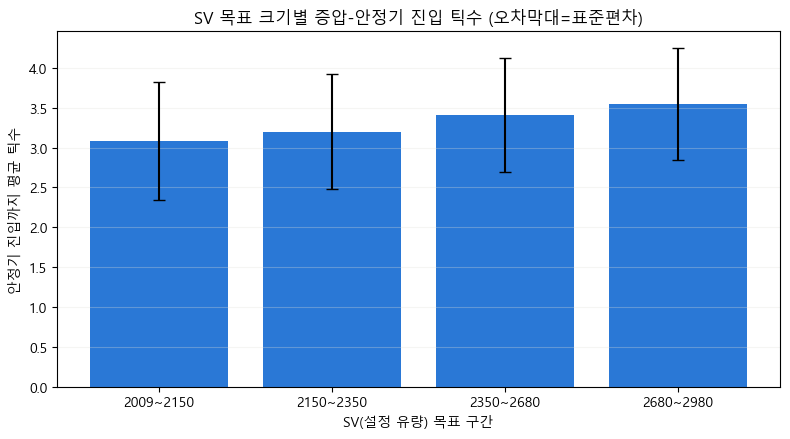

,size,mean,std
SV_Bin,,,
"(2009.999, 2150.0]",14016,3.08,0.74
"(2150.0, 2350.0]",6680,3.20,0.73
"(2350.0, 2680.0]",10065,3.41,0.72
"(2680.0, 2980.0]",2329,3.54,0.70


In [8]:
rs = res[res["Kind"] == "ramp_start"].copy()
edges2 = np.unique(np.percentile(rs["Target_SV"], [0, 20, 40, 60, 80, 100]))
rs["SV_Bin"] = pd.cut(rs["Target_SV"], edges2, include_lowest=True, duplicates="drop")
sv_settle = rs.groupby("SV_Bin", observed=True)["Ticks_To_Settle"].agg(["size", "mean", "std"])
sv_settle.to_csv(f"{OUT}/settle_ticks_by_sv_bin_{PUMP_ID}.csv", encoding="utf-8-sig")

sv_labels = [f"{int(iv.left)}~{int(iv.right)}" for iv in sv_settle.index]
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.bar(sv_labels, sv_settle["mean"], yerr=sv_settle["std"], color=BLUE, capsize=4)
ax.set_xlabel("SV(설정 유량) 목표 구간"); ax.set_ylabel("안정기 진입까지 평균 틱수")
ax.set_title("SV 목표 크기별 증압-안정기 진입 틱수 (오차막대=표준편차)")
ax.grid(alpha=.3, color=GRID, axis="y")
plt.tight_layout()
plt.savefig(f"{OUT}/04_settle_ticks_by_sv.png", dpi=140)
plt.show()
sv_settle.round(2)

SV 목표가 클수록(더 빠른 유량을 목표할수록) 안정기 진입이 약간 더 오래 걸린다
(3.08틱 -> 3.54틱, 완만하지만 일관된 증가). 크기별로 다르긴 하지만 차이가 1틱이 안
되므로, `STEADY_TICK_MIN`을 SV 크기별로 다르게 줄 필요까지는 없어 보이고, 오히려
**전체적으로 2 -> 3~4로 올리는 쪽이 더 근거 있어 보인다.**

## 4. 롤링 baseline - 사출 시작 틱은 "이전 평균"에 들어가는가, "하락 지표"에 들어가는가

`unexplained_pt_dip_events` 의 판정 로직을 그대로 보면:

```python
pt_roll = seg[PT].rolling(3, min_periods=1).mean().shift(1)   # 직전 3틱 평균 (raw PT 값 그대로 사용)
no_shot = Shot_Owned_Active == 0                              # 사출(+4틱)이면 무조건 제외
unexplained = (pt_drop_pct >= 3%) & no_shot & steady
```

`rolling().mean()` 은 **`Shot_Owned_Active` 플래그를 전혀 보지 않는다** - 사출 중이든
아니든 그 틱의 raw PT 값이 그대로 다음 틱들의 baseline 계산에 들어간다. 정리하면:

- 사출 시작 틱(offset 0) 자신은 → `no_shot=False`라서 **"하락 지표"에서는 애초에
  제외**된다 (사출로 설명되니까 안 세는 게 맞다).
- 하지만 그 틱의 (사출 때문에 낮아진) PT 값은 **offset +1, +2, +3 의 baseline 계산에는
  그대로 들어간다.** 이 틱들도 전부 `Shot_Owned_Active=1`(설명구간, +4틱)이라 어차피
  판정 대상이 아니라서 문제는 없다.
- **진짜 애매한 지점은 설명구간이 막 끝난 직후(offset +5, +6, +7)** 다 - 이 틱들은
  `no_shot=True`(판정 대상)인데, 그 baseline(직전 3틱)은 offset +2~+4 를 포함할 수
  있어 **여전히 사출 여파가 남은 값**이 섞인다. 아래 실제 사례로 확인한다.

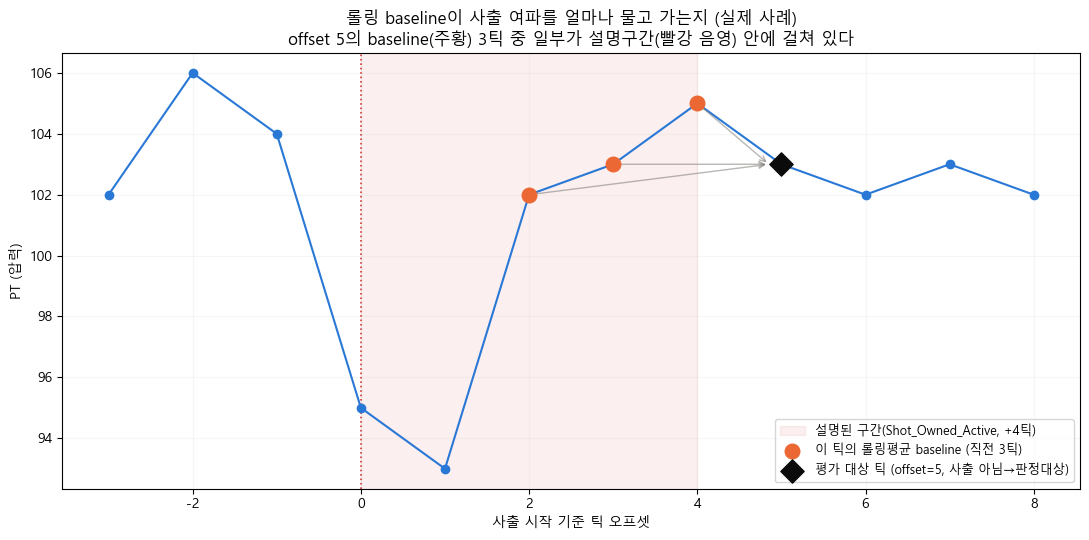

In [9]:
df2, t2 = D.prep(raw, PUMP_ID)
pt_all = df2[t2["PT"]].values
inj_all = (df2[t2["Inj"]] != 0).values
starts_all = np.where(inj_all & ~np.r_[False, inj_all[:-1]])[0]

s = starts_all[3612]  # 임의의 사례 (재현성을 위해 고정 인덱스)
offs = list(range(-3, 9))
vals = [pt_all[np.clip(s + o, 0, len(pt_all) - 1)] for o in offs]

eval_off = INJECTION_DIP_TICKS + 1
base_offs = [eval_off - 3, eval_off - 2, eval_off - 1]
eval_val = vals[offs.index(eval_off)]
base_vals = [vals[offs.index(o)] for o in base_offs]

fig, ax = plt.subplots(figsize=(11, 5.5))
ax.plot(offs, vals, marker="o", ms=6, color=BLUE, lw=1.5, zorder=3)
ax.axvspan(0, INJECTION_DIP_TICKS, color=RED, alpha=.08,
           label=f"설명된 구간(Shot_Owned_Active, +{INJECTION_DIP_TICKS}틱)")
ax.axvline(0, color=RED, ls=":", lw=1.2)
ax.scatter(base_offs, base_vals, color=ORANGE, s=110, zorder=4, label="이 틱의 롤링평균 baseline (직전 3틱)")
ax.scatter([eval_off], [eval_val], color=INK, s=140, marker="D", zorder=5,
           label=f"평가 대상 틱 (offset={eval_off}, 사출 아님→판정대상)")
for o, v in zip(base_offs, base_vals):
    ax.annotate("", xy=(eval_off - 0.15, eval_val), xytext=(o, v),
                arrowprops=dict(arrowstyle="->", color=MUTED, alpha=.6, lw=1))
ax.set_xlabel("사출 시작 기준 틱 오프셋"); ax.set_ylabel("PT (압력)")
ax.set_title(f"롤링 baseline이 사출 여파를 얼마나 물고 가는지 (실제 사례)\n"
             f"offset {eval_off}의 baseline(주황) 3틱 중 일부가 설명구간(빨강 음영) 안에 걸쳐 있다")
ax.grid(alpha=.3, color=GRID)
ax.legend(loc="lower right", fontsize=9)
plt.tight_layout()
plt.savefig(f"{OUT}/05_rolling_baseline_schematic.png", dpi=140)
plt.show()

이 사례에서는 baseline(주황 3점)이 마침 회복이 끝난 값들이라 왜곡이 크지 않지만,
회복이 느린 사출(1절 원본 프로파일의 긴 꼬리 참고)에서는 이 baseline이 여전히 낮게
잡혀 - **설명구간 직후 틱에서 일어나는 진짜 이상 하락을 놓칠 가능성(false negative
방향)**이 있다. 반대로 false positive(원래 없는 하락을 있다고 잘못 세는 것) 방향
위험은 낮다 - baseline이 낮게 깔리면 그 다음 틱과의 차이가 더 작아 보이기 때문이다.

## 5. "사출인데 압력이 안 떨어진" 경우 - 진짜인가, 측정 방식(baseline/판정시점) 문제인가

In [10]:
sens_rows = []
for bt in [1, 2, 3, 4, 5]:
    ev, *_ = D.injection_events(raw, PUMP_ID, before_ticks=bt)
    sens_rows.append(("before_ticks", bt, (ev["Drop_Pct"] <= 0).mean() * 100, ev["Drop_Pct"].mean()))
for at in [1, 2, 3, 4, 6]:
    ev, *_ = D.injection_events(raw, PUMP_ID, after_ticks=at)
    sens_rows.append(("after_ticks", at, (ev["Drop_Pct"] <= 0).mean() * 100, ev["Drop_Pct"].mean()))
sens = pd.DataFrame(sens_rows, columns=["param", "value", "no_drop_rate_pct", "mean_drop_pct"])
sens.to_csv(f"{OUT}/param_sensitivity_{PUMP_ID}.csv", index=False, encoding="utf-8-sig")
sens.round(2)

,param,value,no_drop_rate_pct,mean_drop_pct
0,before_ticks,1,0.08,10.13
1,before_ticks,2,0.34,10.02
2,before_ticks,3,6.54,8.46
3,before_ticks,4,21.90,4.98
4,before_ticks,5,34.61,2.30
5,after_ticks,1,8.20,7.30
6,after_ticks,2,7.12,8.00
7,after_ticks,3,6.71,8.17
8,after_ticks,4,6.54,8.46
9,after_ticks,6,6.52,9.79


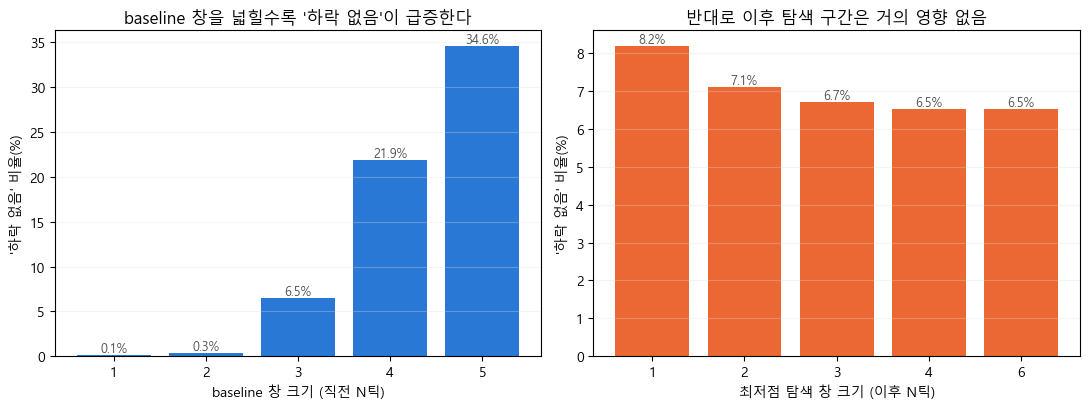

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
sub = sens[sens["param"] == "before_ticks"]
axes[0].bar(sub["value"].astype(str), sub["no_drop_rate_pct"], color=BLUE)
for i, v in enumerate(sub["no_drop_rate_pct"]):
    axes[0].text(i, v, f"{v:.1f}%", ha="center", va="bottom", fontsize=9, color=INK2)
axes[0].set_xlabel("baseline 창 크기 (직전 N틱)"); axes[0].set_ylabel("'하락 없음' 비율(%)")
axes[0].set_title("baseline 창을 넓힐수록 '하락 없음'이 급증한다")
axes[0].grid(alpha=.3, color=GRID, axis="y")

sub2 = sens[sens["param"] == "after_ticks"]
axes[1].bar(sub2["value"].astype(str), sub2["no_drop_rate_pct"], color=ORANGE)
for i, v in enumerate(sub2["no_drop_rate_pct"]):
    axes[1].text(i, v, f"{v:.1f}%", ha="center", va="bottom", fontsize=9, color=INK2)
axes[1].set_xlabel("최저점 탐색 창 크기 (이후 N틱)"); axes[1].set_ylabel("'하락 없음' 비율(%)")
axes[1].set_title("반대로 이후 탐색 구간은 거의 영향 없음")
axes[1].grid(alpha=.3, color=GRID, axis="y")
plt.tight_layout()
plt.savefig(f"{OUT}/06_param_sensitivity.png", dpi=140)
plt.show()

In [12]:
ev3, *_ = D.injection_events(raw, PUMP_ID, before_ticks=3)
no_drop = ev3[ev3["Drop_Pct"] <= 0]
print(f"before_ticks=3 기준 '하락 없음' {len(no_drop):,}건 / 전체 {len(ev3):,}건 "
      f"({len(no_drop)/len(ev3)*100:.2f}%)")
print(f"'하락 없음' 중 Tick_Index<=3(증압이 아직 안 끝났을 가능성) 비율: "
      f"{(no_drop['Tick_Index']<=3).mean()*100:.1f}%  (전체 평균 {(ev3['Tick_Index']<=3).mean()*100:.1f}%)")

before_ticks=3 기준 '하락 없음' 2,224건 / 전체 33,989건 (6.54%)
'하락 없음' 중 Tick_Index<=3(증압이 아직 안 끝났을 가능성) 비율: 99.1%  (전체 평균 24.5%)


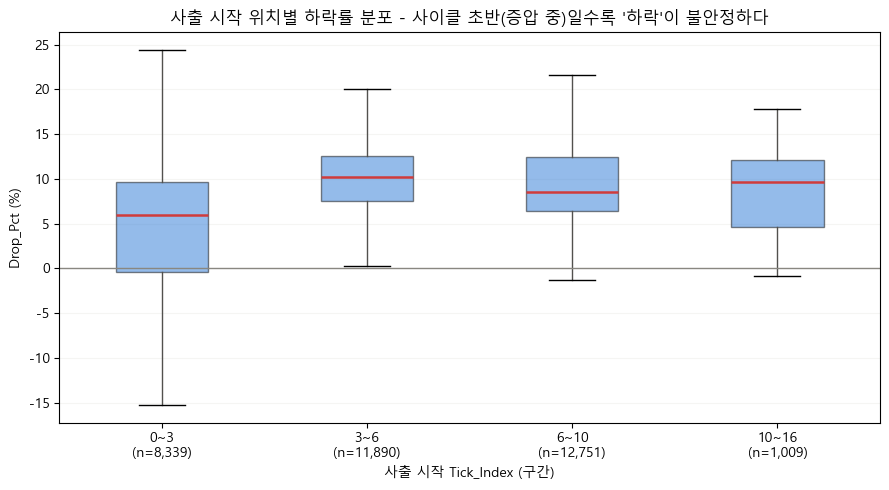

In [13]:
edges3 = [0, 3, 6, 10, 16]
ev3["Tick_Bin"] = pd.cut(ev3["Tick_Index"], edges3, include_lowest=True)
fig, ax = plt.subplots(figsize=(9, 5))
labels3, data3 = [], []
for b, g in ev3.groupby("Tick_Bin", observed=True):
    labels3.append(f"{int(b.left)}~{int(b.right)}\n(n={len(g):,})")
    data3.append(g["Drop_Pct"].values)
bp = ax.boxplot(data3, tick_labels=labels3, showfliers=False, patch_artist=True,
                 boxprops=dict(facecolor=BLUE, alpha=.5, color=INK),
                 medianprops=dict(color=RED, lw=1.8), whiskerprops=dict(color=INK2))
ax.axhline(0, color=MUTED, lw=1)
ax.set_xlabel("사출 시작 Tick_Index (구간)"); ax.set_ylabel("Drop_Pct (%)")
ax.set_title("사출 시작 위치별 하락률 분포 - 사이클 초반(증압 중)일수록 '하락'이 불안정하다")
ax.grid(alpha=.3, color=GRID, axis="y")
plt.tight_layout()
plt.savefig(f"{OUT}/07_drop_pct_by_tick_index.png", dpi=140)
plt.show()

**결론**: "사출인데 압력이 안 떨어진" 6.5%(before_ticks=3 기준)는 **거의 다(99.1%)
사출이 Tick_Index<=3, 즉 아직 증압이 안 끝났을 수 있는 사이클 초반에 일어난 경우**다.
이때 baseline(직전 3틱 평균)이 증압 중이라 아직 낮은 값을 물고 있어, 사출 자체의 진짜
하락과 무관하게 "하락 없음"으로 잘못 계산된다. `before_ticks`를 1~2로 줄이면 이 문제가
0.1~0.3%로 거의 사라진다(=baseline이 증압 구간까지 안 번지므로). **정리하면 진짜
"압력이 안 떨어지는 사출"은 사실상 없고, 측정 방식(baseline 창이 너무 넓음)의 문제였다.**

권고:
- `before_ticks`는 3보다 1~2가 더 정확하다 (baseline이 증압 구간을 덜 침범).
- 또는 Tick_Index < 4(증압 미완료 가능 구간)인 사출은 하락률 통계에서 별도 취급/제외.

## 정리

| 질문 | 결론 |
|---|---|
| 3% 임계값이 적당한가 | 압력대별 자연 변동폭 차이가 커서(80~90 구간이 유독 큼) 고정 3%는 이상적이지 않다. 다만 그 변동폭 자체가 증압 미완료 구간 오염일 수 있음 (아래 참고) |
| 사출 간격/위치 | 97%는 사이클당 1회, 나머지는 9~11틱 간격. 단일사출은 Tick_Index 3~4, 6~7에 쌍봉 |
| 안정기 진입 틱수 | 증압 후 평균 3.2틱(최대 5틱), SV전환 후 평균 2.0틱. `STEADY_TICK_MIN=2`는 다소 이름 |
| 롤링 baseline 오염 | 사출 자신은 하락지표에서 제외되지만, 그 값이 이후 baseline엔 섞인다. 설명구간 직후 1~3틱은 여전히 영향권 |
| "하락 없는 사출" | 진짜가 아니라 baseline 창(3틱)이 증압 미완료 구간을 침범한 측정 아티팩트 (99% 가 Tick_Index<=3) |

출력 파일: `analysis_out/injection_pt_dip_review/` (그림 7개 + CSV 5개).